# Introduction: What to do when noises are nonzero mean
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It shows what to do when the noises have nonzero mean.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Load data from simulation of system dynamic model. These data were created by the code in 
% Lesson 1.4.2, and are the same data used in Lesson 1.4.3.
%
% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOutBias.mat

### Implementing the Kalman filter
The next notebook cells implement the standard Kalman filter, augmented with steps that compute adjustments that enable subracting the effect of the bias from the output of the filter.

In [3]:
% Determine number of states and timesteps and outputs
[nx,nt] = size(x); [nz,~] = size(z);

% Initialize storage
xhat = zeros(nx,1); SigmaX = zeros(nx);
xhatSTDstore = zeros(nx,nt); xboundSTDstore = zeros(nx,nt); % Standard KF, no bias correction
xhatCORstore = zeros(nx,nt); xboundCORstore = zeros(nx,nt); % Corrected KF

In [4]:
% Initialize bias-filter variables; there are three biases
nb = 3;
Bb = [1 0 0; 0 1 0]; % First two bias states affect x
Cb = [0 0 1];        % Third bias state affects z
bhat = zeros(nb,1);  % Initialize bias-filter estimate of bias
SigmaB = diag([1e-5, 1e-5, 4e-5]); % Initialize bias-filter covar.

bhatstore = zeros(nb,nt); bboundstore = zeros(nb,nt);
V = zeros(nx,nb); % V = Vx in Friedland
U = zeros(nx,nb); % U = Ux in Friedland

% If you are interested in checking the quality of the bias estimate, 
% the biases used when making dataset were...
% wbias = [0.001; -0.0001];
% vbias = -0.025;

for k = 2:length(t)
  % Unbiased KF Step 1a: State estimate time update      
  xhat = Ad*xhat + Bd*u(:,k-1); % use prior value of "u"
 
  % Unbiased KF Step 1b: Error covariance time update   
  SigmaX = Ad*SigmaX*Ad' + SigmaW;
  
  % Unbiased KF Step 1c: Estimate system output   
  zhat = Cd*xhat + Dd*u(k); % use present value of "u"

  % Unbiased KF Step 2a: Compute Kalman gain matrix   
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);
 
    % Bias Step 1: Update U, connecting bias and state (prediction)
    U = Ad*V + Bb; % U is nx by nb
  
    % Bias Step 2: Compute S, connecting bias and measurement
    S = Cd*U + Cb; % S is nz by nb

    % Bias Step 3: Compute V, the conversion between bias and deltaX
    V = U - L*S;   % V is nx by nb [need L from KF]
  
    % Bias Step 4: Compute bias estimate covariance 
    SigmaB = SigmaB - (SigmaB*S'/(Cd*SigmaX*Cd' + SigmaV + ...
             S*SigmaB*S'))*S*SigmaB; % [need SigmaX = SigmaXminus from KF]
  
    % Bias Step 5: Compute bias gain
    Lb = SigmaB*(V'*Cd'+Cb')/SigmaV;
  
    % Bias Step 6: Bias estimate
    bhat = (eye(nb)-Lb*S)*bhat + Lb*(z(k)-zhat); % [need zhat from KF]
  
  % Unbiased KF Step 2b: State estimate measurement update   
  xhat = xhat + L*(z(k) - zhat);
   
  % Unbiased KF Step 2c: Error covariance measurement update   
  SigmaX = (eye(nx)-L*Cd)*SigmaX;
 
  % [Store information for evaluation/plotting purposes]  
  xhatSTDstore(:,k) = xhat;
  xhatCORstore(:,k) = xhat + V*bhat; 
  bhatstore(:,k) = bhat;
  xboundSTDstore(:,k) = 3*sqrt(diag(SigmaX));
  xboundCORstore(:,k) = 3*sqrt(diag(SigmaX) + diag(V*SigmaB*V'));
  bboundstore(:,k) = 3*sqrt(diag(SigmaB));
end

### Plot simulation outputs 
The next notebook cells plot the state-vector estimates and the estimation errors (with bounds).

bndErrFrac1 =  99.800
bndErrFrac2 =  95.904
bndErrFrac3 =  3.1968
bndErrFrac4 =  1.6983


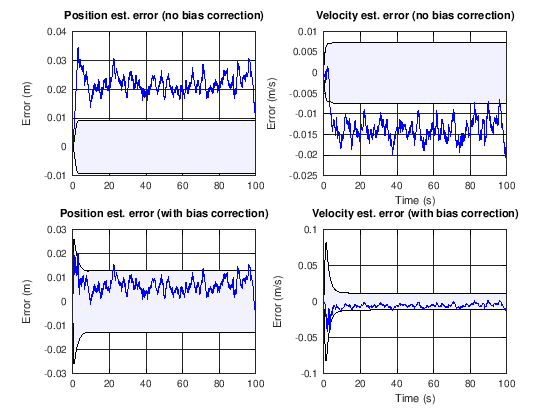

In [5]:
xerr = x - xhatSTDstore; 
subplot(2,2,1); 
fill([t fliplr(t)],[-xboundSTDstore(1,:) fliplr(xboundSTDstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),"Color",'b');
title('Position est. error (no bias correction)'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xerr(1,:))>xboundSTDstore(1,:)))/nt*100

subplot(2,2,2); 
fill([t fliplr(t)],[-xboundSTDstore(2,:) fliplr(xboundSTDstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),"Color",'b');
ht = title('Velocity est. error (no bias correction)'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xerr(2,:))>xboundSTDstore(2,:)))/nt*100

xerr = x - xhatCORstore; 
subplot(2,2,3); 
fill([t fliplr(t)],[-xboundCORstore(1,:) fliplr(xboundCORstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(1,:),"Color",'b');
title('Position est. error (with bias correction)'); ylabel('Error (m)'); 
bndErrFrac3 = length(find(abs(xerr(1,:))>xboundCORstore(1,:)))/nt*100

subplot(2,2,4); 
fill([t fliplr(t)],[-xboundCORstore(2,:) fliplr(xboundCORstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
plot(t,xerr(2,:),"Color",'b');
ht = title('Velocity est. error (with bias correction)'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac4 = length(find(abs(xerr(2,:))>xboundCORstore(2,:)))/nt*100